In [157]:
import torch
device = torch.device('mps')

In [297]:
class Tokenizer:
    def __init__(self):
        self.vocab = {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9,
                      '+': 10, '-': 11, '=': 12, 'x': 13}
        self.vocab['<unk>'] = len(self.vocab)

        self.reverse_vocab = list(self.vocab.keys())
        self.voc_size = len(self.vocab)

    def encode(self, inputs: list[str]):
        encoded_sentences = []
        for input in inputs:
            encoded_input = []
            for char in input:
                if char in self.vocab.keys():
                    encoded_input.append(self.vocab[char])
                else:
                    encoded_input.append(self.vocab['<unk>'])
            encoded_sentences.append(encoded_input)
        return torch.tensor(encoded_sentences, dtype=torch.int)
    
    def decode(self, inputs):
        decoded_sentences = []
        for input in inputs:
            decoded_input = ""
            for word_id in input:
                if word_id < self.voc_size:
                    decoded_input += self.reverse_vocab[word_id]
                else:
                    decoded_input += str(self.reverse_vocab[-1])
            decoded_sentences.append(decoded_input)
        return decoded_sentences

tokenizer = Tokenizer()
print("encode ['1-1=']:", tokenizer.encode(['1-1=']))
print("decode tensor([[ 1, 11,  1, 12]]: ", tokenizer.decode(torch.tensor([[1, 11, 1, 12]])))

encode ['1-1=']: tensor([[ 1, 11,  1, 12]], dtype=torch.int32)
decode tensor([[ 1, 11,  1, 12]]:  ['1-1=']


In [198]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, size: int, modulo_n: int = 7):
        super().__init__()
        self.modulo_n = modulo_n
        self.size = size

        self.data = self.generate(self.size)

    def generate(self, n):
        a, b = torch.randint(0, 9, [n,]), torch.randint(0, 9, [n,])
        targets = a+b % self.modulo_n

        return [f'{a[i]}+{b[i]}=' for i in range(n)], targets.to(torch.uint8)
    
    def __len__(self): return self.size
    def __getitem__(self, idx): return self.data[0][idx], self.data[1][idx]

In [242]:
EMB_DIM = 10

class AttentionBlock(torch.nn.Module):
    INTERN_DIM = 15

    def __init__(self):
        super().__init__()
        self.Q = torch.nn.Linear(EMB_DIM, self.INTERN_DIM)
        self.K = torch.nn.Linear(EMB_DIM, self.INTERN_DIM)
        self.V = torch.nn.Linear(EMB_DIM, EMB_DIM)

    def forward(self, X):
        keys = self.K(X)
        queries = self.Q(X)
        values = self.V(X)

        attn_score = torch.softmax(
            queries @ keys.mT * (self.INTERN_DIM**-0.5), 
            dim=-1
        )

        context_vector = attn_score @ values
        return context_vector

class TransformerBlock(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.attn = AttentionBlock()
        self.ff = torch.nn.Sequential(
            torch.nn.Linear(EMB_DIM, EMB_DIM),
            torch.nn.GELU(),
            torch.nn.Linear(EMB_DIM, EMB_DIM),
            torch.nn.GELU(),
        )
        self.norm1 = torch.nn.LayerNorm(EMB_DIM)
        self.norm2 = torch.nn.LayerNorm(EMB_DIM)

        self.dropout = torch.nn.Dropout(0.2)

    def forward(self, X):
        shortcut = X

        X = self.norm1(X)
        X = self.dropout(self.attn(X))
        X = shortcut + X

        shortcut = X
        X = self.norm2(X)
        X = self.dropout(self.ff(X))
        X = shortcut + X
        return X

In [243]:
class Model(torch.nn.Module):
    def __init__(self, vocab_size: int):
        super().__init__()
        self.emb = torch.nn.Embedding(vocab_size, EMB_DIM)
        self.transformers = torch.nn.Sequential(
            *[TransformerBlock() for _ in range(2)]
        )
        self.ff = torch.nn.Linear(EMB_DIM, vocab_size)

        self.dropout = torch.nn.Dropout(0.1)
        self.norm = torch.nn.LayerNorm(EMB_DIM)

    def forward(self, X):
        X = self.dropout(self.emb(X))
        X = self.transformers(X)
        X = self.norm(X)
        logits = self.ff(X)
        return logits[:, -1, :]

In [244]:
def evaluate(model, tokenizer, criterion):
    model.eval()
    dataset = Dataset(512)
    loader = torch.utils.data.DataLoader(dataset, batch_size=512)
    score = 0
    for inputs, targets in loader:
        inputs_tensor = tokenizer.encode(inputs)
        inputs_tensor, targets = inputs_tensor.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs_tensor)
        loss = criterion(outputs, targets)

        score += loss.item()
    return score / len(loader)

In [270]:
dataset = Dataset(512)
loader = torch.utils.data.DataLoader(dataset, batch_size=64)
tokenizer = Tokenizer()

model = Model(tokenizer.voc_size).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

train_loss = []
val_loss = []

In [313]:
for epoch in range(600):
    model.train()
    epoch_loss = 0
    for inputs, targets in loader:
        inputs_tensor = tokenizer.encode(inputs)
        inputs_tensor, targets = inputs_tensor.to(device), targets.to(device)

        outputs = model(inputs_tensor)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_loss.append(epoch_loss / len(loader))
    val_loss.append(evaluate(model, tokenizer, criterion))
    if not epoch % 60:
        print('Train Loss: ', round(train_loss[-1], 2), ' Validation Loss: ', round(val_loss[-1], 2))

Train Loss:  2.38  Validation Loss:  2.34
Train Loss:  2.38  Validation Loss:  2.32
Train Loss:  2.35  Validation Loss:  2.34
Train Loss:  2.33  Validation Loss:  2.35
Train Loss:  2.32  Validation Loss:  2.27
Train Loss:  2.28  Validation Loss:  2.29
Train Loss:  2.28  Validation Loss:  2.21
Train Loss:  2.27  Validation Loss:  2.26
Train Loss:  2.29  Validation Loss:  2.25
Train Loss:  2.26  Validation Loss:  2.22


In [315]:
calcul = '0+3='
answer = tokenizer.decode([[model(tokenizer.encode([calcul]).to(device)).argmax().cpu().item()]])[0]
print(calcul, answer, sep='')

0+3=4


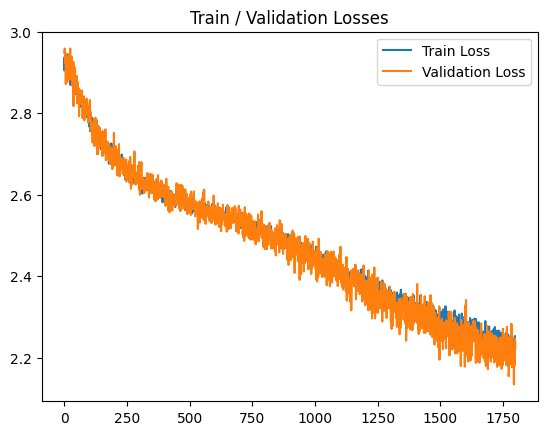

In [316]:
import matplotlib.pyplot as plt

plt.plot(range(len(train_loss)), train_loss, label='Train Loss')
plt.plot(range(len(train_loss)), val_loss, label='Validation Loss')
plt.legend()
plt.title('Train / Validation Losses')
plt.show()

In [317]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = model.emb(torch.tensor([i for i in range(tokenizer.voc_size)]).to(device)).detach().cpu().numpy()

transform = Pipeline([
    ('std', StandardScaler()),
    ('pca', PCA(2))
])

X_scaled = transform.fit_transform(X)

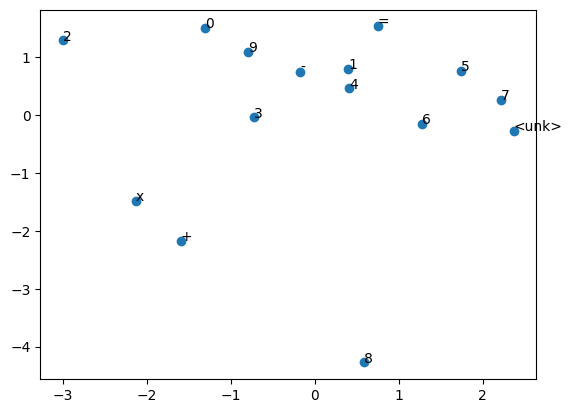

In [320]:
for i in range(len(X_scaled)):
    plt.text(X_scaled[i, 0], X_scaled[i, 1], str(tokenizer.reverse_vocab[i]))

plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.show()